#### Loading Libraries

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### NAV trend analysis

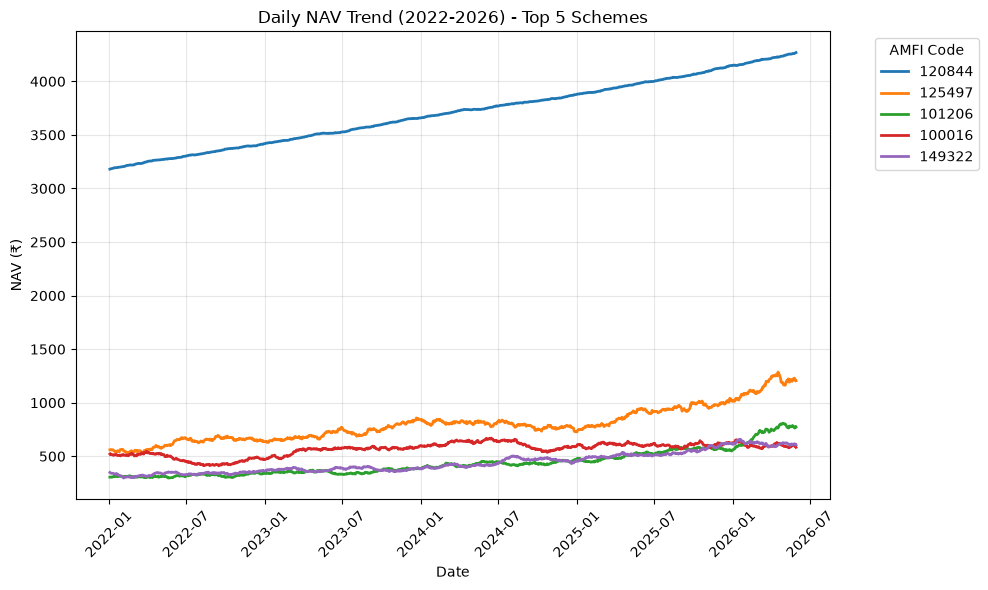

In [ ]:
nav = pd.read_csv(r"D:\BlueStock_Project\Data\Processed\02_nav_history_cleaned_1.csv")
nav['date'] = pd.to_datetime(nav['date'])

top_codes = nav.groupby('amfi_code')['nav'].max().nlargest(5).index

plt.figure(figsize=(10,6))
for code in top_codes:
    data = nav[nav['amfi_code'] == code]
    plt.plot(data['date'], data['nav'], label=str(code), linewidth=2)

plt.title("Daily NAV Trend (2022-2026) - Top 5 Schemes")
plt.xlabel("Date")
plt.ylabel("NAV (₹)")
plt.legend(title="AMFI Code", bbox_to_anchor=(1.05, 1))
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### AUM growth bar chart

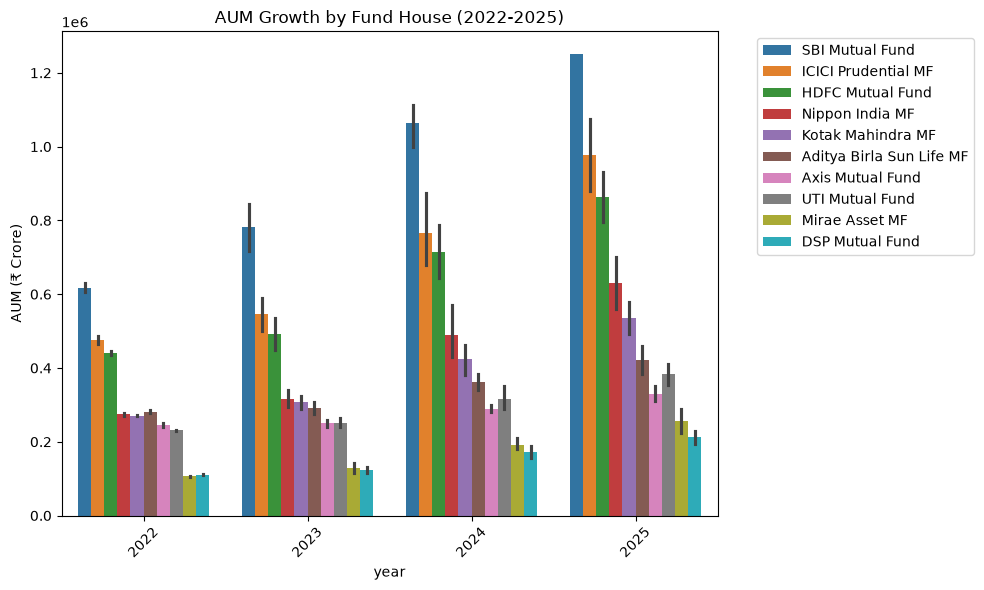

In [9]:
aum = pd.read_csv(r"D:\BlueStock_Project\Data\Processed\03_aum_by_fund_house_cleaned_1.csv")
aum['year'] = pd.to_datetime(aum['date']).dt.year

plt.figure(figsize=(10, 6))
sns.barplot(data=aum, x='year', y='aum_crore', hue='fund_house')
plt.title("AUM Growth by Fund House (2022-2025)")
plt.ylabel("AUM (₹ Crore)")
plt.xticks(rotation=45)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

### SIP inflow time-series

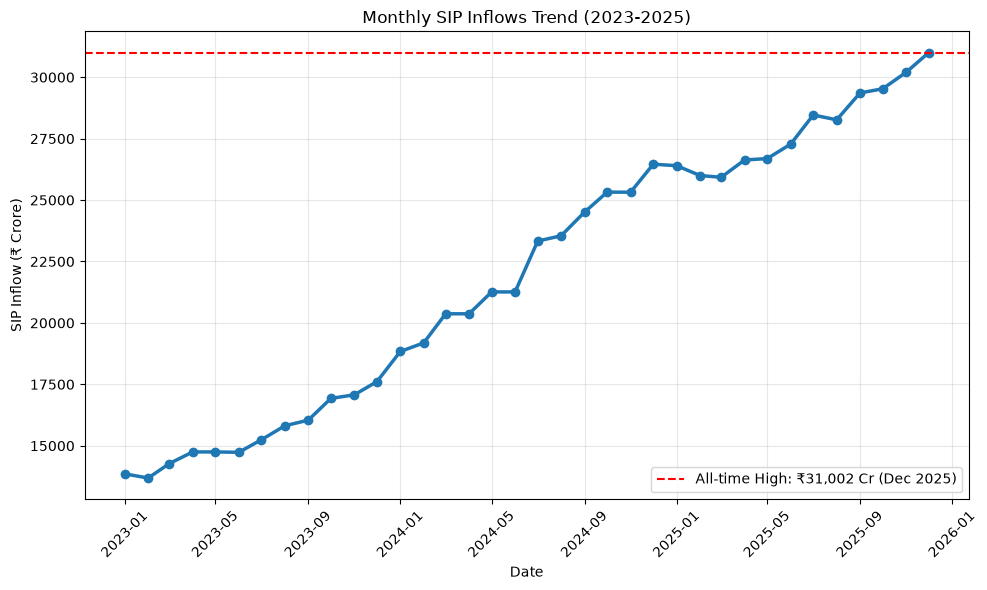

In [11]:
sip = pd.read_csv(r"D:\BlueStock_Project\Data\Processed\04_monthly_sip_inflows_cleaned_1.csv")
sip['date'] = pd.to_datetime(sip['date'])

plt.figure(figsize=(10, 6))
plt.plot(sip['date'], sip['sip_inflow_crore'], marker='o', linewidth=2.5)
plt.title("Monthly SIP Inflows Trend (2023-2025)")
plt.xlabel("Date")
plt.ylabel("SIP Inflow (₹ Crore)")
plt.axhline(y=31002, color='red', linestyle='--', label='All-time High: ₹31,002 Cr (Dec 2025)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Category Inflow Heatmap

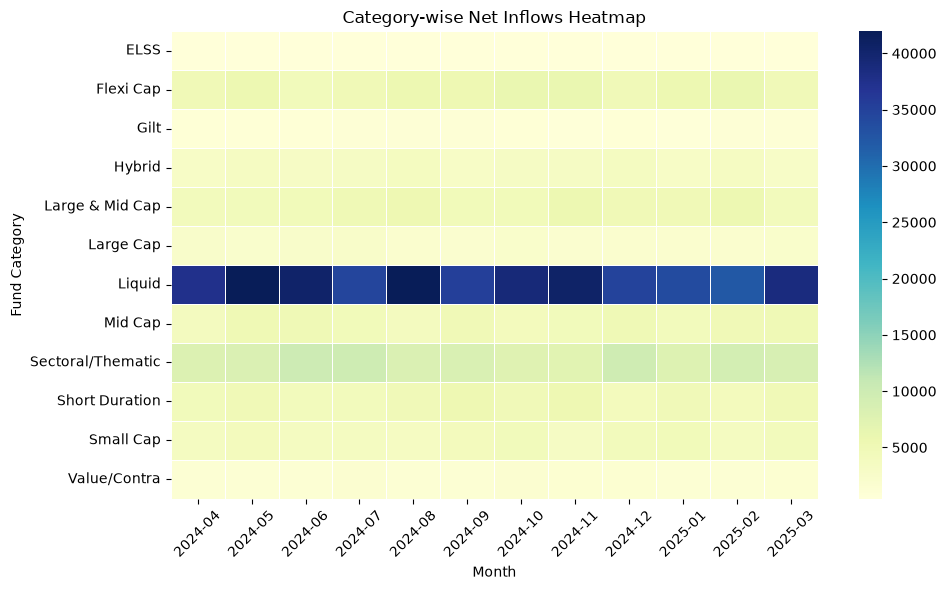

In [13]:
cat = pd.read_csv(r"D:\BlueStock_Project\Data\Processed\05_category_inflows_cleaned_1.csv")
pivot = cat.pivot_table(index='category', columns=pd.to_datetime(cat['date']).dt.strftime('%Y-%m'), 
                       values='net_inflow_crore', aggfunc='sum')

plt.figure(figsize=(10,6))
sns.heatmap(pivot, cmap="YlGnBu", linewidths=0.5)
plt.title("Category-wise Net Inflows Heatmap")
plt.ylabel("Fund Category")
plt.xlabel("Month")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Investor Demographics

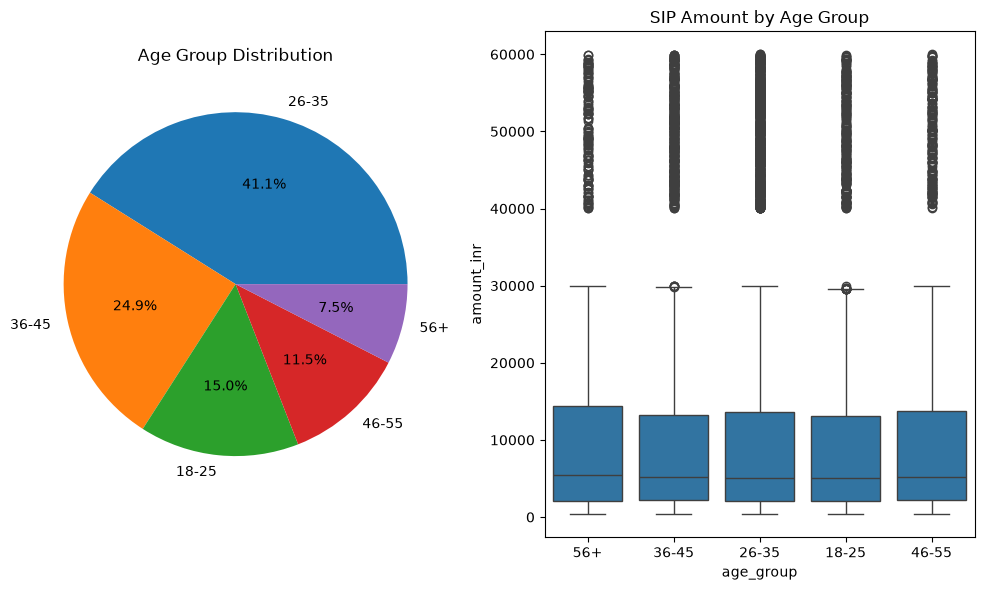

In [15]:
trans = pd.read_csv(r"D:\BlueStock_Project\Data\Processed\08_investor_transactions_cleaned_1.csv")

fig, axes = plt.subplots(1, 2, figsize=(10,6))

# Pie Chart
trans['age_group'].value_counts().plot.pie(autopct='%1.1f%%', ax=axes[0])
axes[0].set_title("Age Group Distribution")

# Box Plot
sns.boxplot(data=trans[trans['transaction_type']=='SIP'], x='age_group', y='amount_inr', ax=axes[1])
axes[1].set_title("SIP Amount by Age Group")
plt.tight_layout()
plt.show()

### Geographic Distribution

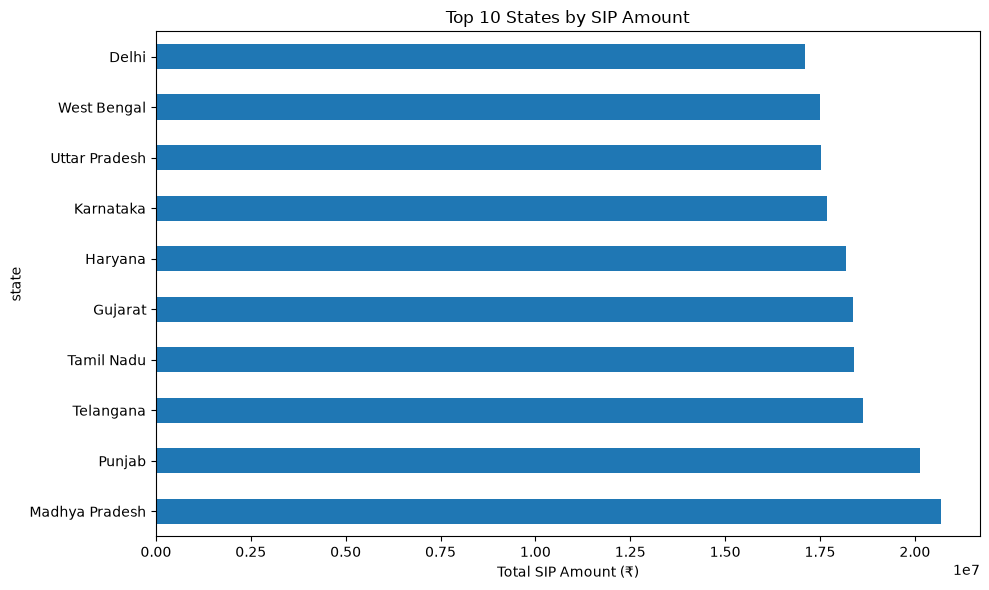

In [16]:
state_amount = trans[trans['transaction_type']=='SIP'].groupby('state')['amount_inr'].sum().nlargest(10)

plt.figure(figsize=(10, 6))
state_amount.plot.barh()
plt.title("Top 10 States by SIP Amount")
plt.xlabel("Total SIP Amount (₹)")
plt.tight_layout()
plt.show()

### Folio Count Growth

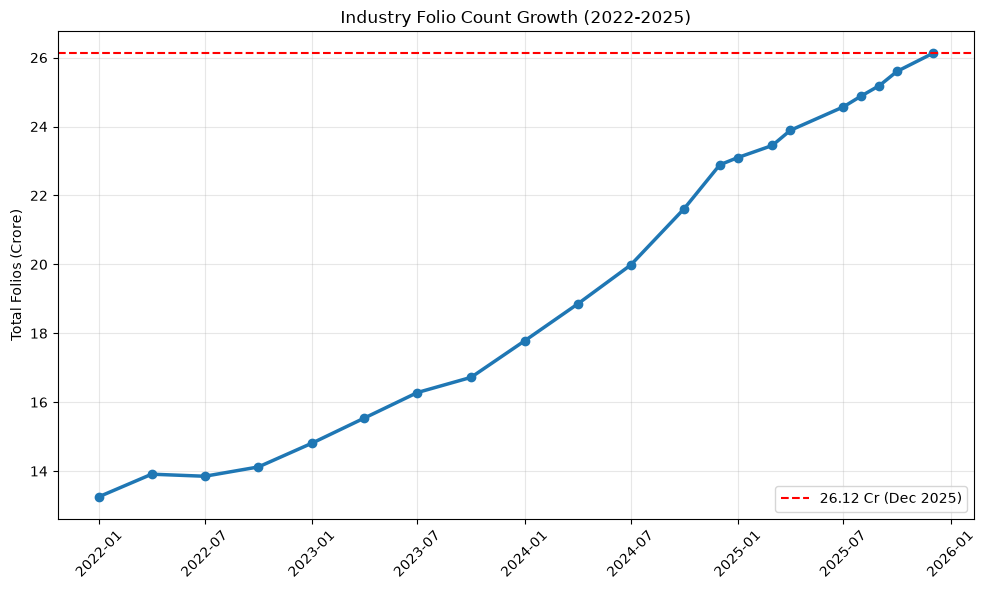

In [17]:
folio = pd.read_csv(r"D:\BlueStock_Project\Data\Processed\06_industry_folio_count_cleaned_1.csv")
folio['date'] = pd.to_datetime(folio['date'])

plt.figure(figsize=(10, 6))
plt.plot(folio['date'], folio['total_folios_crore'], marker='o', linewidth=2.5)
plt.title("Industry Folio Count Growth (2022-2025)")
plt.ylabel("Total Folios (Crore)")
plt.axhline(y=26.12, color='red', linestyle='--', label='26.12 Cr (Dec 2025)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### NAV Return Correlation Heatmap

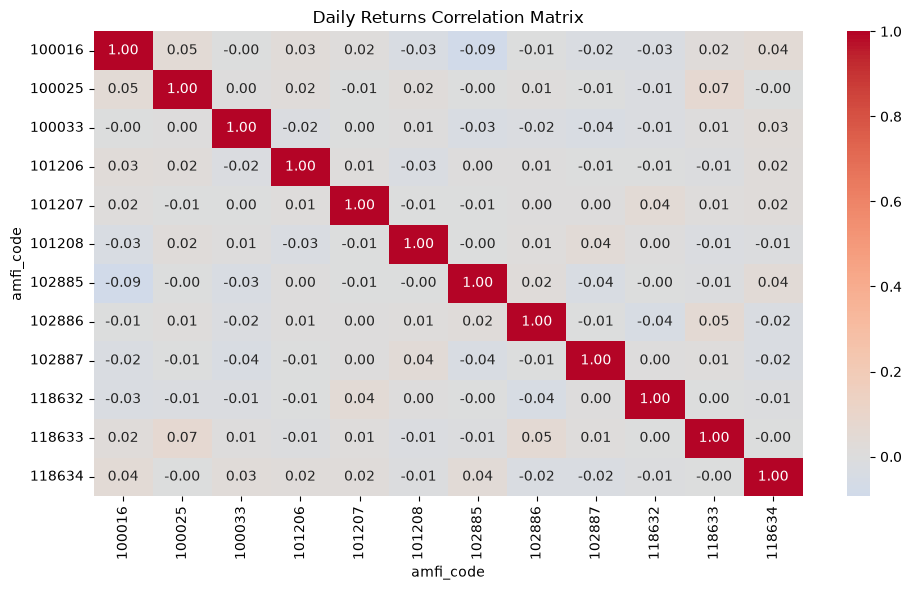

In [18]:
pivot_nav = nav.pivot(index='date', columns='amfi_code', values='nav').pct_change()
corr = pivot_nav.corr().iloc[:12, :12]   # Top 12 funds

plt.figure(figsize=(10, 6))
sns.heatmap(corr, annot=True, cmap="coolwarm", center=0, fmt='.2f')
plt.title("Daily Returns Correlation Matrix")
plt.tight_layout()
plt.show()

### Sector Allocation Donut

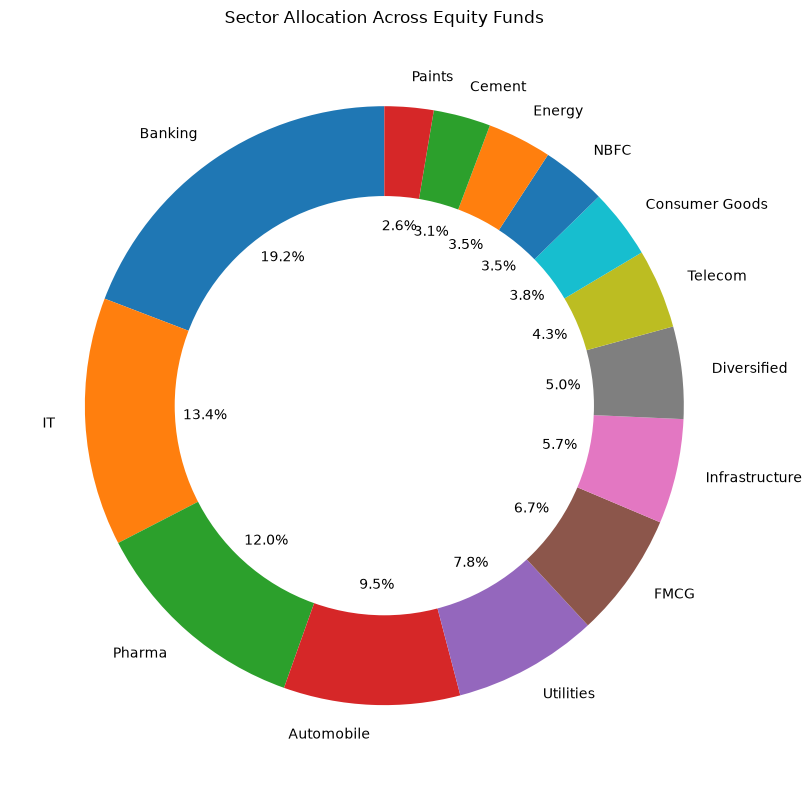

In [26]:
holdings = pd.read_csv(r"D:\BlueStock_Project\Data\Processed\09_portfolio_holdings_cleaned_1.csv")

sector = holdings.groupby('sector')['weight_pct'].sum().sort_values(ascending=False)

plt.figure(figsize=(10, 8))
plt.pie(sector, labels=sector.index, autopct='%1.1f%%', startangle=90)
centre_circle = plt.Circle((0,0), 0.70, fc='white')
plt.gca().add_artist(centre_circle)
plt.title("Sector Allocation Across Equity Funds")
plt.tight_layout()
plt.show()

### Key Findings

Finding 1: SBI Mutual Fund dominates AUM with ₹12.5 Lakh Crore as of Mar 2025.

Finding 2: Small Cap and Mid Cap categories saw strongest inflows during 2024 bull phase.

Finding 3: SIP inflows reached all-time high of ₹31,002 Cr in Dec 2025.

Finding 4: 26-35 age group contributes maximum SIP volume.

Finding 5: Maharashtra and Karnataka lead in geographic SIP contribution.

Finding 6: Folio count doubled from 13.26 Cr to 26.12 Cr in 4 years.

Finding 7: Expense ratio <1% funds consistently outperform peers on 3Y returns.

Finding 8: Strong positive correlation between Large Cap NAV movements.

Finding 9: Technology and Financials dominate portfolio holdings.

Finding 10: Redemption pressure increased during 2024 market corrections.